In [1]:
# Open training, testing subsets from https://doi.org/10.1021/acs.energyfuels.0c01533
from csv import DictReader

with open('schweidtmann_train.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_train = [r for r in reader]
csv_file.close()
with open('schweidtmann_test.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_test = [r for r in reader]
csv_file.close()

print(len(compounds_train), len(compounds_test))

# Filter out compounds with `n.a.` RON or MON data
compounds_train = [c for c in compounds_train if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']
compounds_test = [c for c in compounds_test if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']

print(len(compounds_train), len(compounds_test))

430 75
265 51


In [2]:
# Format data for training
from ecnet.datasets.structs import QSPRDataset

smiles_train = [c[' SMILES'] for c in compounds_train]
ron_train = [float(c['Meas RON']) for c in compounds_train]
mon_train = [float(c['Meas MON']) for c in compounds_train]
targets_train = [[ron_train[i], mon_train[i]] for i in range(len(mon_train))]

smiles_test = [c[' SMILES'] for c in compounds_test]
ron_test = [float(c['Meas RON']) for c in compounds_test]
mon_test = [float(c['Meas MON']) for c in compounds_test]
targets_test = [[ron_test[i], mon_test[i]] for i in range(len(mon_test))]

dataset_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
dataset_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [3]:
# Select most-influential descriptors w.r.t. RON and MON for NN input variables
from ecnet.tasks.feature_selection import select_rfr

print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
# Retain descriptors such that 99.9% of descriptor-property correlation is retained
desc_idx, desc_imp = select_rfr(dataset_train, total_importance=0.999, n_estimators=64, n_jobs=8)
dataset_train.set_desc_index(desc_idx)
dataset_test.set_desc_index(desc_idx)
print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
print(dataset_train.desc_names[:5], desc_imp[:5])

torch.Size([265, 5305]) torch.Size([51, 5305])
torch.Size([265, 1047]) torch.Size([51, 1047])
['SssCH2', 'ChiA_B(s)', 'GATS2m', 'Eta_L_A', 'TI2_L'] [0.22684040614732648, 0.16110501153759582, 0.12684631027913687, 0.03365376620411026, 0.027632107714281432]


Model 0
Epoch: 0 | Train loss: 1685.6382480197483 | Valid loss: 9223372036854775807
Epoch: 25 | Train loss: 125.74875841237078 | Valid loss: 149.72483825683594
Epoch: 50 | Train loss: 65.54945057570332 | Valid loss: 69.87224578857422
Epoch: 75 | Train loss: 44.876096889226126 | Valid loss: 31.595338821411133
Epoch: 100 | Train loss: 33.798401591753716 | Valid loss: 32.464481353759766
Epoch: 125 | Train loss: 34.62810964295358 | Valid loss: 29.998855590820312
Epoch: 150 | Train loss: 42.251327688043766 | Valid loss: 34.49052047729492
Epoch: 175 | Train loss: 20.808932824568316 | Valid loss: 26.547950744628906
Epoch: 200 | Train loss: 25.77872141443118 | Valid loss: 60.00077819824219
Epoch: 225 | Train loss: 18.7883109950056 | Valid loss: 14.998384475708008
Epoch: 250 | Train loss: 24.162558603768396 | Valid loss: 26.44435691833496
Epoch: 275 | Train loss: 17.156283253371114 | Valid loss: 15.027647972106934
Epoch: 300 | Train loss: 32.5954939042679 | Valid loss: 23.323076248168945
Epoch:

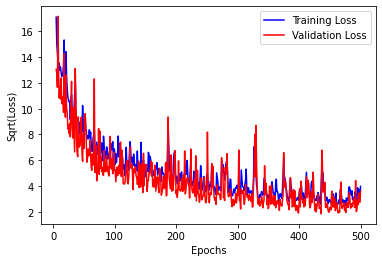

In [4]:
# Create ECNet model
from ecnet import ECNet
from math import sqrt
from matplotlib import pyplot as plt

models = []

for i in range(10):

    print(f'Model {i}')
    model = ECNet(dataset_train.desc_vals.shape[1], dataset_train.target_vals.shape[1], 1024, 1, 0.0)
    train_loss, valid_loss = model.fit(
        dataset=dataset_train, valid_size=0.25, shuffle=True, verbose=25,
        patience=64, epochs=1024, lr=0.0005, lr_decay=0.0, batch_size=8
    )
    models.append(model)

# Plot sqrt(MSE loss)
train_loss = [sqrt(l) for l in train_loss][5:]
valid_loss = [sqrt(l) for l in valid_loss][5:]
epoch = [i for i in range(5, len(train_loss) + 5)]
plt.clf()
plt.xlabel('Epochs')
plt.ylabel('Sqrt(Loss)')
plt.plot(epoch, train_loss, color='blue', label='Training Loss')
plt.plot(epoch, valid_loss, color='red', label='Validation Loss')
plt.legend(loc='upper right')
plt.show()

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_hat_trains = []
for i in range(len(models)):
    y_hat_trains.append(models[i](dataset_train.desc_vals).detach().numpy())
y_hat_trains = np.asarray(y_hat_trains)
y_hat_train = np.mean(y_hat_trains, axis=0)
y_train = dataset_train.target_vals.numpy()

y_hat_tests = []
for i in range(len(models)):
    y_hat_tests.append(models[i](dataset_test.desc_vals).detach().numpy())
y_hat_tests = np.asarray(y_hat_tests)
y_hat_test = np.mean(y_hat_tests, axis=0)
y_test = dataset_test.target_vals.numpy()

y_hat_train_ron = [y[0] for y in y_hat_train]
y_hat_train_mon = [y[1] for y in y_hat_train]
y_train_ron = [y[0] for y in y_train]
y_train_mon = [y[1] for y in y_train]

y_hat_test_ron = [y[0] for y in y_hat_test]
y_hat_test_mon = [y[1] for y in y_hat_test]
y_test_ron = [y[0] for y in y_test]
y_test_mon = [y[1] for y in y_test]

mae_ron_train = mean_absolute_error(y_hat_train_ron, y_train_ron)
mae_ron_test = mean_absolute_error(y_hat_test_ron, y_test_ron)
mae_mon_train = mean_absolute_error(y_hat_train_mon, y_train_mon)
mae_mon_test = mean_absolute_error(y_hat_test_mon, y_test_mon)
r2_ron_train = r2_score(y_hat_train_ron, y_train_ron)
r2_ron_test = r2_score(y_hat_test_ron, y_test_ron)
r2_mon_train = r2_score(y_hat_train_mon, y_train_mon)
r2_mon_test = r2_score(y_hat_test_mon, y_test_mon)

print(f'RON Train: {mae_ron_train} | {r2_ron_train}')
print(f'RON Test: {mae_ron_test} | {r2_ron_test}')
print(f'MON Train: {mae_mon_train} | {r2_mon_train}')
print(f'MON Test: {mae_mon_test} | {r2_mon_test}')

RON Train: 1.2413911819458008 | 0.994470365926338
RON Test: 4.717143535614014 | 0.926143361838624
MON Train: 1.1277443170547485 | 0.9942385308810749
MON Test: 4.038842678070068 | 0.9161430175643359


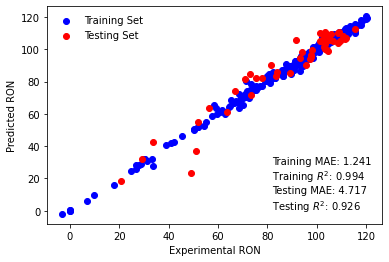

In [6]:
from matplotlib.offsetbox import AnchoredText

plt.clf()
plt.xlabel('Experimental RON')
plt.ylabel('Predicted RON')
plt.scatter(y_train_ron, y_hat_train_ron, color='blue', label='Training Set')
plt.scatter(y_test_ron, y_hat_test_ron, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(mae_ron_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_ron_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_ron_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_ron_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()

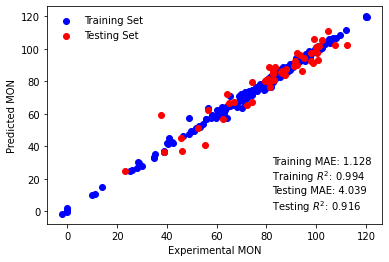

In [7]:
plt.clf()
plt.xlabel('Experimental MON')
plt.ylabel('Predicted MON')
plt.scatter(y_train_mon, y_hat_train_mon, color='blue', label='Training Set')
plt.scatter(y_test_mon, y_hat_test_mon, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(mae_mon_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_mon_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_mon_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_mon_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()